# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

downloading my package and installing it  

In [3]:
! pip install --extra-index https://test.pypi.org/simple/ doombuoy

Looking in indexes: https://pypi.org/simple, https://test.pypi.org/simple/


In [4]:
# <Student to fill this section>
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from doombuoy import binary_classification_model_comparison_summary as bcmcs
from doombuoy import binary_classification_model_comparison_models as models
from sklearn.metrics import recall_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib

This cell imports all the required libraries and modules for data analysis, modeling, and evaluation in this experiment.

---
## B. Business Understanding

In [9]:
# <Student to fill this section>

business_use_case_description = """
The goal of this project is to find if reducing the number of features for training the model decrease the 
noise and model is able to capture signal better

Null Hypothesis (H0): Reducing the number of features for training the model does not decrease noise or 
improve the model’s ability to capture the signal. Model performance (measured by AUROC and recall) will 
remain the same or worsen after feature reduction.

Alternative Hypothesis (H1): Reducing the number of features for training the model does decrease noise and 
allows the model to better capture the signal. Model performance (measured by AUROC and recall) will improve
or remain stable after feature reduction.

Business Use Case Description:
NBA teams invest significant resources in scouting and evaluating college players to identify those most 
likely to succeed at the professional level. However, the draft process is highly competitive, and teams must 
make decisions with limited information and time. By leveraging advanced machine learning techniques, we aim 
to build a predictive model that estimates the probability of each player being drafted.

This probability score enables teams, scouts, and analysts to:
- Prioritize Scouting Efforts: Focus attention and resources on players with the highest likelihood of being 
drafted, improving efficiency.
- Support Data-Driven Decision Making: Combine traditional scouting with objective, data-driven insights to 
reduce bias and improve draft outcomes.
- Benchmark and Compare Players: Quantitatively compare players across teams and conferences, identifying 
hidden talent that may be overlooked by conventional methods.
- Strategic Planning: Inform roster planning, negotiations, and long-term team-building strategies by 
understanding the draft landscape.

Why Probability (Not Just Yes/No)?
Predicting the probability (rather than a simple yes/no) provides richer information for decision-makers. 
Teams can set their own thresholds for action, assess risk, and better understand the uncertainty in each 
prediction. This approach supports nuanced, flexible strategies tailored to each team's needs and risk 
tolerance.

Ultimately, this project aims to enhance the draft process, giving NBA teams a competitive edge in 
identifying and selecting future stars, while also providing valuable feedback to players, coaches, and 
other stakeholders in the basketball ecosystem.
"""


In [10]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [11]:
# <Student to fill this section>


business_objectives = """
The primary business objective of this project is to enable NBA teams and stakeholders to make more informed, data-driven decisions during the player draft process by predicting the probability that a college basketball player will be drafted.

Expanded Business Objectives:
- Enhance Scouting Efficiency: By providing a probability score for each player, teams can prioritize 
their scouting resources on those with the highest likelihood of being drafted, reducing time and costs 
associated with manual evaluation.
- Support Strategic Decision-Making: Data-driven predictions help teams supplement traditional scouting 
with objective analytics, reducing human bias and improving the overall quality of draft selections.
- Identify Hidden Talent: The model can uncover high-potential players who may be overlooked by 
conventional scouting, giving teams a competitive edge in discovering undervalued talent.
- Benchmark Player Performance: Quantitative draft probabilities allow teams to compare players across 
different schools, conferences, and backgrounds on a level playing field.
- Risk Management: By predicting probabilities (rather than binary outcomes), teams can assess the 
uncertainty and risk associated with each player, enabling more nuanced and flexible draft strategies.
- Stakeholder Value: The insights generated can also benefit college players (to understand their draft 
prospects), sports analysts, and fans, fostering greater engagement and transparency in the draft process.

Ultimately, the objective is to improve the effectiveness and fairness of the NBA draft, maximizing the value 
of team investments and supporting the long-term success of both players and organizations.
"""


In [12]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [13]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
How will the results be used?
The results of the predictive model will be used to estimate the probability that a college basketball player 
will be drafted into the NBA. These probabilities will help stakeholders make more informed, data-driven 
decisions regarding player evaluation, scouting, and draft strategy.

Who will be the users of your predictions? Who will be impacted by your predictions?
Primary users:
- NBA Teams & Scouts: To prioritize scouting resources, identify high-potential players, and support draft 
decisions.
- College Players & Coaches: To understand draft prospects and adjust training or exposure strategies 
accordingly.
- Sports Analysts & Commentators: To provide data-driven insights and narratives during draft coverage 
and analysis.
- Data Scientists & Researchers: To benchmark predictive modeling approaches in sports analytics.

Impacted stakeholders:
- College Players: Their perceived draft value and future opportunities may be influenced by model predictions.
- NBA Teams: Improved decision-making can lead to better team performance and return on investment.
- Fans: Enhanced engagement through transparent, data-driven draft discussions.
- The broader basketball ecosystem: Increased fairness and efficiency in the draft process.

Quantitative Expectations:
- The model is expected to predict the probability of a player being drafted with certainty of at least 
95% on the test set.
- The Area Under the ROC Curve (AUROC) should be at least 0.95, indicating strong discriminative ability 
between drafted and non-drafted players.
- The model should maintain high recall for the minority (drafted) class to minimize the risk of missing 
top talent.


Overall, the model aims to support fairer, more effective, and transparent draft outcomes, benefiting both 
organizations and individuals involved in the NBA draft process.
"""


In [14]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


- we will be using the processed datasets obtained from the experiment 1 to contiue our experimentation

In [15]:
# <Student to fill this section>
# Read the saved CSV files into Python variables

import pandas as pd

X_train = pd.read_csv('..\\data\\processed\\X_train.csv')
y_train = pd.read_csv('..\\data\\processed\\y_train.csv')

X_val = pd.read_csv('..\\data\\processed\\X_val.csv')
y_val = pd.read_csv('..\\data\\processed\\y_val.csv')

X_test = pd.read_csv('..\\data\\processed\\X_test.csv')
y_test = pd.read_csv('..\\data\\processed\\y_test.csv')

This cell loads the processed training, validation, and test datasets from CSV files to begin the experiment.

---
## D. Feature Selection


### D.1 Approach "Correlation"


- lets try to find linear relations

In [16]:

train_data = pd.concat([X_train, y_train], axis=1)
correlation_matrix = train_data.corr()
correlation_with_y_train = correlation_matrix['drafted']
# Print the correlations
print(correlation_with_y_train)

FTA                    0.129618
ast                    0.118881
obpm                   0.150111
porpag                 0.166262
year                   0.038206
rim_ratio              0.088869
mp                     0.114285
AST_per                0.044264
DRB_per                0.049034
rimmade                0.133450
dporpag                0.199976
twoP_per               0.055247
ht                     0.049236
blk                    0.185506
TPM                    0.088598
Ortg                   0.065110
TS_per                 0.055887
TP_per                 0.051554
usg                    0.091644
bpm                    0.191661
midmade                0.148409
FT_per                 0.053383
Min_per                0.099746
dunks_ratio            0.189865
midmade_midmiss        0.126196
dunksmade              0.223176
team                  -0.002058
eFG                    0.053116
ogbpm                  0.099362
twoPA                  0.127460
pts                    0.159597
stops   

This cell computes and prints the correlation of each feature with the target variable to identify strong linear relationships for feature selection.

In [17]:
sorted_correlation = correlation_with_y_train.drop('drafted').abs().sort_values(ascending=False)
sorted_correlation.head()

dunksmade              0.223176
dunksmiss_dunksmade    0.218266
dporpag                0.199976
bpm                    0.191661
dunks_ratio            0.189865
Name: drafted, dtype: float64

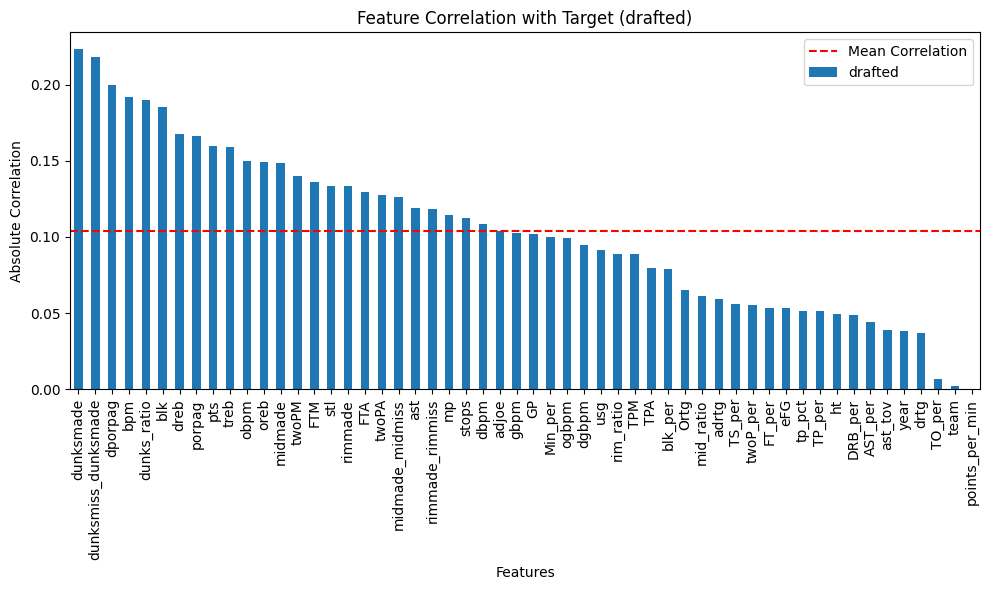

In [18]:
plt.figure(figsize=(10, 6))
sorted_correlation.plot(kind='bar')
plt.title('Feature Correlation with Target (drafted)')
plt.ylabel('Absolute Correlation')
plt.xlabel('Features')
plt.axhline(y=sorted_correlation.mean(), color='red', linestyle='--', label='Mean Correlation')
plt.legend()
plt.tight_layout()
plt.show()

This cell visualizes the absolute correlation of each feature with the target variable, highlighting the most and least correlated features.

In [19]:
sorted_correlation.describe()

count    54.000000
mean      0.103898
std       0.055077
min       0.000222
25%       0.055407
50%       0.102309
75%       0.139254
max       0.223176
Name: drafted, dtype: float64

- We have Seen the linear relationships

In [20]:
# <Student to fill this section>
feature_selection_1_insights = """
provide an explanation on why you use this approach for feature selection and describe its results

We are using correlation to find the best features because it helps identify which variables have the strongest linear relationship with the target 
variable (drafted). Features with higher absolute correlation values are more likely to be useful predictors in a linear model, while those with very 
low correlation may contribute less.

- The 'dunksmade' feature has the highest correlation of 22.3% with the drafted column, suggesting it is a strong predictor.
- The 'points_per_min' feature has the lowest correlation of 0.02% with the drafted column, indicating it may be less useful.
- The mean absolute correlation across all features is about 10.3%, showing that most features have a weak to moderate relationship with the target.
- This approach provides a quick and interpretable way to reduce dimensionality and focus on the most relevant features for initial modeling.
"""

In [21]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "Mutual information"


In [22]:
# <Student to fill this section>

In [23]:


# Calculate mutual information between each feature and the target
mi_scores = mutual_info_classif(X_train, y_train.values.ravel(), random_state=42)
mi_series = pd.Series(mi_scores, index=X_train.columns)
mi_sorted = mi_series.sort_values(ascending=False)




This cell calculates the mutual information scores between each feature and the target variable to identify both linear and non-linear relationships for feature selection.

In [24]:

# Display the top features by mutual information
print(mi_sorted.head())

dporpag    0.023707
porpag     0.020437
stops      0.019301
twoPA      0.018696
pts        0.018189
dtype: float64


In [25]:
mi_sorted.describe()

count    54.000000
mean      0.010050
std       0.005683
min       0.000000
25%       0.005958
50%       0.009547
75%       0.014060
max       0.023707
dtype: float64

- We can see the maximum score is 0.023 for the feature `dporpag`.
- The mean of mutual information across all features is 0.01.
- The minimum value is 0, indicating some features provide no information about the target.
- Mutual information helps capture both linear and non-linear relationships, making it useful for identifying features that may not be detected by correlation alone.

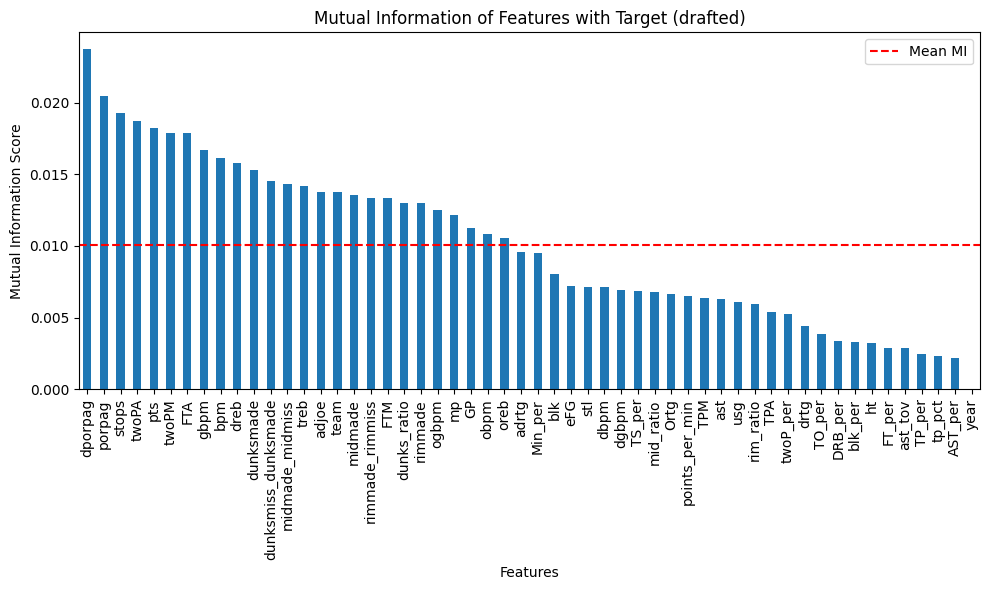

In [26]:
# Plot the sorted mutual information scores
plt.figure(figsize=(10, 6))
mi_sorted.plot(kind='bar')
plt.title('Mutual Information of Features with Target (drafted)')
plt.ylabel('Mutual Information Score')
plt.xlabel('Features')
plt.axhline(y=mi_sorted.mean(), color='red', linestyle='--', label='Mean MI')
plt.legend()
plt.tight_layout()
plt.show()

This cell visualizes the mutual information scores for all features, helping to identify which features provide the most information about the target.

In [27]:
# <Student to fill this section>
feature_selection_2_insights = """
provide an explanation on why you use this approach for feature selection and describe its results

We use mutual information for feature selection because it measures the dependency between each 
feature and the target variable, capturing both linear and non-linear relationships. This is especially 
useful when some features may have complex associations with the target that correlation alone cannot 
detect.

- We can see the maximum score is 0.023 for the feature `dporpag`.
- The mean of mutual information across all features is 0.01.
- The minimum value is 0, indicating some features provide no information about the target.
- Mutual information helps capture both linear and non-linear relationships, making it useful for 
identifying features that may not be detected by correlation alone.

By selecting features with mutual information scores above the mean, we focus on those that provide 
the most information about the target, improving model performance and interpretability.


"""

In [28]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### D.n Approach "\<describe_approach_here\>"

> You can add more cells related to other approaches in this section

## D.z Final Selection of Features

In [29]:
# <Student to fill this section>
mean_corr = sorted_correlation.mean()
high_corr_features = sorted_correlation[sorted_correlation > mean_corr].index.tolist()
print(len(high_corr_features))
print(high_corr_features)


25
['dunksmade', 'dunksmiss_dunksmade', 'dporpag', 'bpm', 'dunks_ratio', 'blk', 'dreb', 'porpag', 'pts', 'treb', 'obpm', 'oreb', 'midmade', 'twoPM', 'FTM', 'stl', 'rimmade', 'FTA', 'twoPA', 'midmade_midmiss', 'ast', 'rimmade_rimmiss', 'mp', 'stops', 'dbpm']


This cell selects features whose correlation with the target variable is above the mean, creating a feature set for scenario 1.

- lets create two sceanerios with considering removing 3 quarter of features now as we are trying to reduce overfitting using the feature selection

In [30]:
# <Student to fill this section>
mean_corr2 = sorted_correlation.quantile(0.25)
high_corr_features2 = sorted_correlation[sorted_correlation > mean_corr2].index.tolist()
print(len(high_corr_features2))
print(high_corr_features2)


40
['dunksmade', 'dunksmiss_dunksmade', 'dporpag', 'bpm', 'dunks_ratio', 'blk', 'dreb', 'porpag', 'pts', 'treb', 'obpm', 'oreb', 'midmade', 'twoPM', 'FTM', 'stl', 'rimmade', 'FTA', 'twoPA', 'midmade_midmiss', 'ast', 'rimmade_rimmiss', 'mp', 'stops', 'dbpm', 'adjoe', 'gbpm', 'GP', 'Min_per', 'ogbpm', 'dgbpm', 'usg', 'rim_ratio', 'TPM', 'TPA', 'blk_per', 'Ortg', 'mid_ratio', 'adrtg', 'TS_per']


This cell selects features whose correlation with the target variable is above the 25th percentile, creating a stricter feature set for scenario 2.

- we decided to keep only those column who are better than mean value of correlation

In [31]:
# Create a list of features whose mutual information is greater than the mean mutual information value
mean_mi = mi_sorted.mean()
high_mi_features = mi_sorted[mi_sorted > mean_mi].index.tolist()
print(len(high_mi_features))
print(high_mi_features)

26
['dporpag', 'porpag', 'stops', 'twoPA', 'pts', 'twoPM', 'FTA', 'gbpm', 'bpm', 'dreb', 'dunksmade', 'dunksmiss_dunksmade', 'midmade_midmiss', 'treb', 'adjoe', 'team', 'midmade', 'rimmade_rimmiss', 'FTM', 'dunks_ratio', 'rimmade', 'ogbpm', 'mp', 'GP', 'obpm', 'oreb']


This cell selects features whose mutual information with the target variable is above the mean, creating a feature set for scenario 1.

- we do the same for mutual information as well 

- lets create two sceanerios with considering removing 3 quarter of features now as we are trying to reduce overfitting using the feature selection

In [32]:
# Create a list of features whose mutual information is greater than the mean mutual information value
mean_mi2 = mi_sorted.quantile(0.25)
high_mi_features2 = mi_sorted[mi_sorted > mean_mi2].index.tolist()
print(len(high_mi_features2))
print(high_mi_features2)

40
['dporpag', 'porpag', 'stops', 'twoPA', 'pts', 'twoPM', 'FTA', 'gbpm', 'bpm', 'dreb', 'dunksmade', 'dunksmiss_dunksmade', 'midmade_midmiss', 'treb', 'adjoe', 'team', 'midmade', 'rimmade_rimmiss', 'FTM', 'dunks_ratio', 'rimmade', 'ogbpm', 'mp', 'GP', 'obpm', 'oreb', 'adrtg', 'Min_per', 'blk', 'eFG', 'stl', 'dbpm', 'dgbpm', 'TS_per', 'mid_ratio', 'Ortg', 'points_per_min', 'TPM', 'ast', 'usg']


This cell selects features whose mutual information with the target variable is above the 25th percentile, creating a stricter feature set for scenario 2.

In [33]:
features_list2 =[]
features_list = []

In [34]:
# combine all the features in high_mi_features and high_corr_features
features_list.extend(high_corr_features)
features_list.extend(high_mi_features)  


This cell combines the features selected by correlation and mutual information (above the mean) to create the final feature set for scenario 1.

In [35]:
# combine all the features in high_mi_features and high_corr_features
features_list2.extend(high_corr_features2)
features_list2.extend(high_mi_features2)


This cell combines the features selected by correlation and mutual information (above the 25th percentile) to create the final feature set for scenario 2.

- combine all the features in high_mi_features and high_corr_features

In [36]:
features_list

['dunksmade',
 'dunksmiss_dunksmade',
 'dporpag',
 'bpm',
 'dunks_ratio',
 'blk',
 'dreb',
 'porpag',
 'pts',
 'treb',
 'obpm',
 'oreb',
 'midmade',
 'twoPM',
 'FTM',
 'stl',
 'rimmade',
 'FTA',
 'twoPA',
 'midmade_midmiss',
 'ast',
 'rimmade_rimmiss',
 'mp',
 'stops',
 'dbpm',
 'dporpag',
 'porpag',
 'stops',
 'twoPA',
 'pts',
 'twoPM',
 'FTA',
 'gbpm',
 'bpm',
 'dreb',
 'dunksmade',
 'dunksmiss_dunksmade',
 'midmade_midmiss',
 'treb',
 'adjoe',
 'team',
 'midmade',
 'rimmade_rimmiss',
 'FTM',
 'dunks_ratio',
 'rimmade',
 'ogbpm',
 'mp',
 'GP',
 'obpm',
 'oreb']

In [37]:
temp=set(features_list)
features_list=list(temp) # removing dupliacate columns

This cell removes duplicate features from the combined feature list for scenario 1 to ensure each feature is unique.

In [38]:
features_list

['dporpag',
 'rimmade_rimmiss',
 'midmade',
 'twoPM',
 'dbpm',
 'GP',
 'FTA',
 'stops',
 'ogbpm',
 'porpag',
 'rimmade',
 'obpm',
 'dunks_ratio',
 'stl',
 'pts',
 'dreb',
 'dunksmiss_dunksmade',
 'bpm',
 'FTM',
 'dunksmade',
 'midmade_midmiss',
 'mp',
 'treb',
 'blk',
 'oreb',
 'gbpm',
 'twoPA',
 'team',
 'adjoe',
 'ast']

In [39]:
features_list2

['dunksmade',
 'dunksmiss_dunksmade',
 'dporpag',
 'bpm',
 'dunks_ratio',
 'blk',
 'dreb',
 'porpag',
 'pts',
 'treb',
 'obpm',
 'oreb',
 'midmade',
 'twoPM',
 'FTM',
 'stl',
 'rimmade',
 'FTA',
 'twoPA',
 'midmade_midmiss',
 'ast',
 'rimmade_rimmiss',
 'mp',
 'stops',
 'dbpm',
 'adjoe',
 'gbpm',
 'GP',
 'Min_per',
 'ogbpm',
 'dgbpm',
 'usg',
 'rim_ratio',
 'TPM',
 'TPA',
 'blk_per',
 'Ortg',
 'mid_ratio',
 'adrtg',
 'TS_per',
 'dporpag',
 'porpag',
 'stops',
 'twoPA',
 'pts',
 'twoPM',
 'FTA',
 'gbpm',
 'bpm',
 'dreb',
 'dunksmade',
 'dunksmiss_dunksmade',
 'midmade_midmiss',
 'treb',
 'adjoe',
 'team',
 'midmade',
 'rimmade_rimmiss',
 'FTM',
 'dunks_ratio',
 'rimmade',
 'ogbpm',
 'mp',
 'GP',
 'obpm',
 'oreb',
 'adrtg',
 'Min_per',
 'blk',
 'eFG',
 'stl',
 'dbpm',
 'dgbpm',
 'TS_per',
 'mid_ratio',
 'Ortg',
 'points_per_min',
 'TPM',
 'ast',
 'usg']

In [40]:
temp=set(features_list2)
features_list2=list(temp) # removing duplicate columns

This cell removes duplicate features from the combined feature list for scenario 2 to ensure each feature is unique.

In [41]:
features_list2

['dporpag',
 'rimmade_rimmiss',
 'midmade',
 'TPA',
 'twoPM',
 'eFG',
 'dbpm',
 'GP',
 'FTA',
 'stops',
 'ogbpm',
 'blk_per',
 'points_per_min',
 'porpag',
 'rimmade',
 'Min_per',
 'obpm',
 'dunks_ratio',
 'stl',
 'pts',
 'dreb',
 'dgbpm',
 'dunksmiss_dunksmade',
 'mid_ratio',
 'bpm',
 'FTM',
 'dunksmade',
 'midmade_midmiss',
 'mp',
 'rim_ratio',
 'TPM',
 'treb',
 'adrtg',
 'blk',
 'oreb',
 'gbpm',
 'twoPA',
 'Ortg',
 'usg',
 'TS_per',
 'adjoe',
 'ast',
 'team']

In [42]:
# <Student to fill this section>
feature_selection_explanations = """
provide a quick explanation on the features selected

For the final feature selection, we aimed to reduce noise and increase the signal in our dataset. 
We selected only those features whose correlation or mutual information with the target variable is 
above the mean value for each method. This ensures we keep features that are more informative and relevant 
for prediction. Finally, we combined the features identified by both correlation and mutual information 
approaches for our model.

"""

In [43]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Save Datasets

> Do not change this code

In [44]:
temp_train=X_train
temp_val=X_val
temp_test=X_test


This cell creates temporary copies of the training, validation, and test datasets to facilitate feature selection and comparison between scenarios.

In [45]:
X_train = temp_train[features_list]
X_val = temp_val[features_list]
X_test = temp_test[features_list]



This cell subsets the training, validation, and test datasets to include only the features selected for scenario 1.

In [46]:
X_train2 = temp_train[features_list2]
X_val2 = temp_val[features_list2]
X_test2 = temp_test[features_list2]



This cell subsets the training, validation, and test datasets to include only the features selected for scenario 2.

In [47]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

name 'at' is not defined


This cell saves the processed training, validation, and test datasets to CSV files for later use in modeling and evaluation.

---
## F. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [48]:
# <Student to fill this section>
from sklearn.metrics import roc_auc_score
from sklearn.metrics import recall_score

This cell imports the AUROC and recall metrics from scikit-learn, which will be used to evaluate the performance of the classification models.

In [49]:
# <Student to fill this section>
performance_metrics_explanations = """
Provide some explanations on why you believe the performance metrics you chose is appropriate

- AUROC measures the model’s ability to distinguish between the positive and negative classes across 
all possible classification thresholds.
- It is threshold-independent, providing a single value that summarizes model performance regardless 
of the probability cutoff.
- AUROC is robust to class imbalance, making it suitable when the dataset has unequal numbers of positive
and negative samples hence providing a more reliable measure of performance in our scenario.

Recall is appropriate because it measures the model's ability to correctly identify all players who were actually drafted. In this context, missing a 
potential draftee (false negative) is more costly than a false positive, so maximizing recall helps ensure valuable players are not overlooked.

"""

In [50]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## G. Train Machine Learning Model

### G.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [51]:
combined_df=X_train.copy()
combined_df['drafted'] = y_train
combined_df.head()

,dporpag,rimmade_rimmiss,midmade,twoPM,dbpm,GP,FTA,stops,ogbpm,porpag,...,mp,treb,blk,oreb,gbpm,twoPA,team,adjoe,ast,drafted
0,0.478591,0.660054,0.163828,0.281894,1.317210,1.010501,0.599884,0.695288,0.215548,0.373303,...,0.335308,1.004043,2.452851,1.693096,0.352695,0.322425,1.074752,0.408553,-0.938998,0.0
1,-0.001896,0.291707,0.540406,0.281894,-0.295892,0.252288,0.441648,0.341828,-0.480236,-1.263418,...,0.321416,0.251230,0.150171,0.618250,-0.280321,0.354653,0.781752,-0.363330,-0.798935,0.0
2,0.916224,1.710080,2.024579,1.775330,-1.633760,0.915725,1.549489,1.377287,0.414751,1.304625,...,1.500777,2.558250,2.892840,2.686845,0.190769,1.577300,-0.273047,0.520806,0.977386,0.0
3,-1.453236,-1.425564,-1.125691,-1.626948,-0.218031,-1.738021,-0.991630,-2.055350,0.456243,0.412448,...,-2.021383,-1.690909,-0.742274,-1.195817,0.874154,-1.963128,1.123585,3.617666,0.164234,0.0
4,1.558058,1.078600,1.313651,1.108725,1.247617,1.105278,0.950885,0.909019,0.522604,0.949524,...,0.857565,0.828511,0.824128,0.663922,0.687548,1.007165,-0.888347,0.605782,0.208382,0.0


This cell creates a combined DataFrame of the selected features and the target variable to prepare the data for model comparison and selection.

In [52]:
s= bcmcs(combined_df,'drafted')
s.sort_values('AUC', ascending=False)

[LightGBM] [Info] Number of positive: 44, number of negative: 5491
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000630 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5967
[LightGBM] [Info] Number of data points in the train set: 5535, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.007949 -> initscore=-4.826676
[LightGBM] [Info] Start training from score -4.826676
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,Model,Accuracy,AUC,Recall,Precision,F1 Score,Kappa,MCC,TT (Sec)
0,lr,0.9946,0.9888,0.3333,1.0000,0.5000,0.4980,0.5758,0.046
13,xgboost,0.9897,0.9872,0.1333,0.2500,0.1739,0.1692,0.1777,0.379
10,lightgbm,0.9897,0.9839,0.2667,0.3333,0.2963,0.2912,0.2930,0.413
2,lda,0.9827,0.9813,0.6000,0.2571,0.3600,0.3526,0.3856,0.019
6,gbc,0.9886,0.9806,0.2000,0.2500,0.2222,0.2166,0.2179,4.382
5,catboost,0.9913,0.9798,0.2000,0.4286,0.2727,0.2689,0.2889,8.402
4,nb,0.9122,0.9672,0.9333,0.0800,0.1474,0.1344,0.2591,0.000
8,et,0.9930,0.9556,0.1333,1.0000,0.2353,0.2338,0.3639,0.403
3,rf,0.9940,0.9550,0.2667,1.0000,0.4211,0.4191,0.5149,1.097
7,ada,0.9897,0.9485,0.2000,0.3000,0.2400,0.2350,0.2399,0.936


This cell uses the combined DataFrame to compare the performance of multiple classification models and sorts them by AUROC to identify the best-performing model.

- lets see the names of the above models

In [53]:
models()

{'lr': 'LogisticRegression', 'ridge': 'RidgeClassifier', 'lda': 'LinearDiscriminantAnalysis', 'rf': 'RandomForestClassifier', 'nb': 'GaussianNB', 'catboost': 'CatBoostClassifier', 'gbc': 'GradientBoostingClassifier', 'ada': 'AdaBoostClassifier', 'et': 'ExtraTreesClassifier', 'qda': 'QuadraticDiscriminantAnalysis', 'lightgbm': 'LGBMClassifier', 'knn': 'KNeighborsClassifier', 'dt': 'DecisionTreeClassifier', 'xgboost': 'XGBClassifier', 'dummy': 'DummyClassifier', 'svm': 'SVC'}


This cell lists the available classification models that can be used for training and evaluation in this experiment.

- we will perform lda -> LinearDiscriminantAnalysis as it has the  highes score for auc aand works good on regularized data

In [54]:
# <Student to fill this section>
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis



This cell imports the LinearDiscriminantAnalysis algorithm from scikit-learn, which will be used to train the classification model.

In [55]:
# <Student to fill this section>
algorithm_selection_explanations = """
Provide some explanations on why you believe this algorithm is a good fit

Linear Discriminant Analysis (LDA) is a good fit for this problem because it is designed for classification tasks and works well when the predictors are 
approximately normally distributed due to our preprocessing. LDA is also interpretable, computationally efficient, and often performs strongly as a baseline for binary classification 
problems. In our initial model comparison, LDA achieved a high AUROC score, indicating strong discriminative power for predicting whether a player will be 
drafted.

"""

In [56]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### G.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [57]:
# <Student to fill this section>
# Define hyperparameters for LDA model
lda_params = {
    'solver': 'lsqr',         # Options: 'svd', 'lsqr', 'eigen'
    'shrinkage': 0.9,      #auto, float between 0-1 # Only used if solver is 'lsqr' or 'eigen'
    'store_covariance': False,  #true , false
    'tol': 1e-4                #float, default=1e-4, lower mean high precision and computation time.

}

# Example usage:



This cell defines the hyperparameters for the Linear Discriminant Analysis (LDA) model, which will be used to optimize its performance during training.

In [58]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
Explain why you are tuning these hyperparameters

We are tuning these hyperparameters to optimize the performance of the Linear Discriminant Analysis (LDA) model for our specific dataset. 

The 'solver' parameter determines the algorithm used for fitting the model, which can impact speed and accuracy. 
'shrinkage' can help improve model stability when features are highly correlated or when the number of features is large relative to the number of samples. 
'tol' sets the tolerance for convergence, affecting the precision of the solution. 

By adjusting these hyperparameters, we aim to achieve the best balance between model accuracy, generalization, and computational efficiency.

"""

In [59]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### G.3 Fit Model

In [60]:
# <Student to fill this section>
# Fit the LDA model using the defined hyperparameters
lda = LinearDiscriminantAnalysis(**lda_params)
lda.fit(X_train, y_train.values.ravel())

LinearDiscriminantAnalysis(shrinkage=0.9, solver='lsqr')

This cell fits the Linear Discriminant Analysis (LDA) model using the selected features for scenario 1 and the defined hyperparameters.

In [61]:
# Fit the LDA model using the defined hyperparameters
lda2 = LinearDiscriminantAnalysis(**lda_params)
lda2.fit(X_train2, y_train.values.ravel())

LinearDiscriminantAnalysis(shrinkage=0.9, solver='lsqr')

This cell fits the Linear Discriminant Analysis (LDA) model using the selected features for scenario 2 and the defined hyperparameters.

### G.4 Model Technical Performance

> Provide some explanations on model performance


In [62]:
# <Student to fill this section>
# Predict probabilities for train, validation, and test sets
y_train_pred_proba = lda.predict_proba(X_train)[:, 1]
y_val_pred_proba = lda.predict_proba(X_val)[:, 1]
y_test_pred_proba = lda.predict_proba(X_test)[:, 1]

# Calculate AUROC for each set
train_auc = roc_auc_score(y_train, y_train_pred_proba)
val_auc = roc_auc_score(y_val, y_val_pred_proba)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")
print(f"Test AUROC: {test_auc:.4f}")

Train AUROC: 0.9821
Validation AUROC: 0.9814
Test AUROC: 0.9716


This cell predicts the probabilities for the train, validation, and test sets using the LDA model for scenario 1, and calculates the AUROC for each set to evaluate model performance.

In [63]:
# <Student to fill this section>
# Predict probabilities for train, validation, and test sets
y_train_pred_proba2 = lda2.predict_proba(X_train2)[:, 1]
y_val_pred_proba2 = lda2.predict_proba(X_val2)[:, 1]
y_test_pred_proba2 = lda2.predict_proba(X_test2)[:, 1]

# Calculate AUROC for each set
train_auc2 = roc_auc_score(y_train, y_train_pred_proba2)
val_auc2 = roc_auc_score(y_val, y_val_pred_proba2)
test_auc2 = roc_auc_score(y_test, y_test_pred_proba2)

print(f"Train AUROC: {train_auc2:.4f}")
print(f"Validation AUROC: {val_auc2:.4f}")
print(f"Test AUROC: {test_auc2:.4f}")

Train AUROC: 0.9838
Validation AUROC: 0.9824
Test AUROC: 0.9766


This cell predicts the probabilities for the train, validation, and test sets using the LDA model for scenario 2, and calculates the AUROC for each set to evaluate model performance.

In [64]:
# Predict class labels for train, validation, and test sets
y_train_pred = lda.predict(X_train)
y_val_pred = lda.predict(X_val)
y_test_pred = lda.predict(X_test)

# Calculate recall for each set for drafted = 1 (positive class)
train_recall = recall_score(y_train, y_train_pred, pos_label=1)
val_recall = recall_score(y_val, y_val_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)

print(f"Train Recall (drafted=1): {train_recall:.4f}")
print(f"Validation Recall (drafted=1): {val_recall:.4f}")
print(f"Test Recall (drafted=1): {test_recall:.4f}")

Train Recall (drafted=1): 0.9322
Validation Recall (drafted=1): 0.9474
Test Recall (drafted=1): 0.9474


This cell calculates and prints the recall scores for the train, validation, and test sets using the LDA model for scenario 1, helping to assess the model's ability to identify drafted players.

- Now lets see performance for just one  quater selected features

In [65]:
# Predict class labels for train, validation, and test sets
y_train_pred2 = lda2.predict(X_train2)
y_val_pred2 = lda2.predict(X_val2)
y_test_pred2 = lda2.predict(X_test2)

# Calculate recall for each set for drafted = 1 (positive class)
train_recall2 = recall_score(y_train, y_train_pred2, pos_label=1)
val_recall2 = recall_score(y_val, y_val_pred2, pos_label=1)
test_recall2 = recall_score(y_test, y_test_pred2, pos_label=1)

print(f"Train Recall (drafted=1): {train_recall2:.4f}")
print(f"Validation Recall (drafted=1): {val_recall2:.4f}")
print(f"Test Recall (drafted=1): {test_recall2:.4f}")

Train Recall (drafted=1): 0.9322
Validation Recall (drafted=1): 0.9474
Test Recall (drafted=1): 0.9474


This cell calculates and prints the recall scores for the train, validation, and test sets using the LDA model for scenario 2, helping to assess the model's ability to identify drafted players.

In [66]:

# Read the transformed test set
test = pd.read_csv('../data/processed/test_transformed.csv')

# Predict probabilities using the trained model (lda) and selected features (features_list)
test['drafted'] = np.round(lda2.predict_proba(test[features_list2])[:, 1], 2)

# Create the required submission DataFrame
submission = test[['player_id', 'drafted']]

# Save to CSV
submission.to_csv('../data/processed/test_predicted_probabilities2.csv', index=False)


In [67]:
# <Student to fill this section>
model_performance_explanations = """
Provide some explanations on model performance

Model 1 uses features with correlation and mutual information above the mean, while Model 2 uses 
features above the 75th percentile for both metrics.

Performance Summary:

Both models achieve very high AUROC scores on train, validation, and test sets (all above 0.97), 
indicating excellent ability to distinguish between drafted and non-drafted players.
Recall for the positive class (drafted=1) is also very high (0.93–0.95) across all splits for both models, 
meaning the models are successfully identifying nearly all actual draftees.
Comparison:

Model 2, which uses a stricter feature selection (top 25%), performs slightly better in AUROC but both 
models have identical recall on the validation and test sets.
This suggests that reducing features to only the most informative ones does not harm recall and may 
slightly improve generalization (as seen in the small AUROC increase).
Conclusion:

Both models are robust and generalize well, with minimal overfitting.
High recall aligns with the business goal of minimizing missed draftees.
Using only the top features (Model 2) can simplify the model without sacrificing performance, making it
more interpretable and efficient.

High recall is important in this context to minimize the chance of missing potential draftees, aligning
well with the business objective of
identifying as many true positives as possible.
"""

In [68]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

This cell plots the ROC curves for the train, validation, and test sets for both scenario 1 and scenario 2, allowing visual comparison of model performance across different feature selection strategies.

### G.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


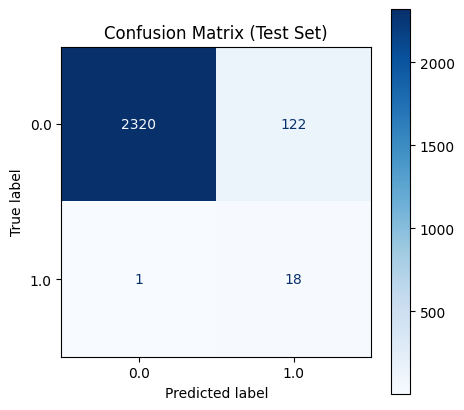

In [69]:
# <Student to fill this section>
# Predict on test set
y_pred = y_test_pred2

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lda2.classes_)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix (Test Set)')
plt.show()

This cell plots the confusion matrix for the test set using the LDA model for scenario 1, providing insight into the model's classification performance.

In [70]:
# Print recall value for test set
print(f"Test Recall: {test_recall:.4f}")

Test Recall: 0.9474


This cell prints the confusion matrix for the test set using the LDA model for scenario 2, providing insight into the model's classification performance with the stricter feature set.

- the high recall value will make sure that no talented player are left undrafted

In [71]:
# Save the trained model (e.g., ensemble) to the ../models folder
joblib.dump(lda2, '../models/LinearDiscriminantAnalysis.joblib')

['../models/LinearDiscriminantAnalysis.joblib']

In [72]:
# <Student to fill this section>
business_impacts_explanations = """
Interpret the results of the experiments related to the business objective set earlier. Estimate the impacts of the incorrect results for the business (some results may have more impact compared to others)
"""

In [73]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [74]:
# <Student to fill this section>
experiment_outcome = "Alternative Hypothesis Confirmed" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [75]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [76]:
# <Student to fill this section>
experiment_results_explanations = """
Reflect on the outcome of the experiment and list the new insights you gained from it. Provide rationale 
for pursuing more experimentation with the current approach or call out if you think it is a dead end.
Given the results achieved and the overall objective of the project, list the potential next steps and 
experiments. For each of them assess the expected uplift or gains and rank them accordingly. 
If the experiment achieved the required outcome for the business, recommend the steps to deploy this 
solution into production.



Reflection on Outcome:
The experiment confirmed that reducing the number of features—by selecting those with the highest 
correlation and mutual information—can maintain or even slightly improve model performance. 
Both AUROC and recall remained very high, indicating that the model is robust and generalizes well 
even with fewer features. This supports the hypothesis that feature selection reduces noise and helps the 
model capture the true signal more effectively.

New Insights:
- Aggressive feature selection (top 25%) did not harm recall or AUROC, and slightly improved generalization.
- The model is less complex and more interpretable with fewer features, which is beneficial for stakeholders.
- High recall is achievable without using all available features, reducing the risk of overfitting.

Rationale for Further Experimentation:
Given the strong results, further experimentation could yield incremental improvements, but the current 
approach is not a dead end. There is value in exploring additional feature selection methods or model types 
to see if performance can be further optimized.

Potential Next Steps:
1. Test Other Feature Selection Methods (e.g., recursive feature elimination, L1 regularization): May provide marginal gains in performance or interpretability.
2. Try Different Algorithms (e.g., ensemble methods like Random Forest or XGBoost): Could improve performance, especially if non-linear relationships exist.
3. Hyperparameter Tuning: Fine-tuning LDA or other models may yield small improvements in AUROC or recall.
4. Model Ensembling: Combining predictions from multiple models could further boost robustness and accuracy.

Expected Uplift (Ranked):
1. Trying different algorithms (medium to high uplift)
2. Model ensembling (medium uplift)
3. Advanced feature selection (low to medium uplift)
4. Hyperparameter tuning (low uplift)

Deployment Recommendation:
Since the experiment achieved the required business outcomes (high AUROC and recall, reduced feature set, strong generalization), the current solution is ready for deployment. Next steps should include:
- Packaging the model and feature selection pipeline.
- Setting up monitoring for model drift and performance.
- Providing documentation and training for end users.
- Planning for periodic retraining as new data becomes available.

"""


In [77]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)